Notebook to train a diffusion model to match the distribution of data from MD simulations of a 2D Muller Brown potential, and then test out various interpolation schemes to compute transition paths.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

from torch.utils.data import TensorDataset, DataLoader

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
# Utility Functions
def slerp(v0, v1, t, DOT_THRESHOLD=0.9995):
    """
    Spherical linear interpolation between two vectors.
    Source: Andrej Karpathy's gist: https://gist.github.com/karpathy/00103b0037c5aaea32fe1da1af553355
    Args:
        v0 (torch.Tensor): the first vector
        v1 (torch.Tensor): the second vector
        t (torch.Tensor): scalar from 0 to 1 parameterizing the interpolation
    """
    v0 = v0.detach().cpu().numpy()
    v1 = v1.detach().cpu().numpy()

    dot = np.sum(v0 * v1 / (np.linalg.norm(v0) * np.linalg.norm(v1)))
    if np.abs(dot) > DOT_THRESHOLD:
        v2 = (1 - t) * v0 + t * v1  # simple linear interpolation
    else:
        theta_0 = np.arccos(dot)  # angle between latent vectors
        sin_theta_0 = np.sin(theta_0)
        theta_t = theta_0 * t
        sin_theta_t = np.sin(theta_t)
        s0 = np.sin(theta_0 - theta_t) / sin_theta_0
        s1 = sin_theta_t / sin_theta_0
        v2 = s0 * v0 + s1 * v1
    return v2

def from_numpy(*args, **kwargs):
    return torch.from_numpy(*args, **kwargs).float().to(device)


def get_numpy(tensor):
    return tensor.to("cpu").detach().numpy()


# Plotting
def visualize_mb_data(dataset, title="Muller Brown Training Data"):
    mb_dataloader = torch.utils.data.DataLoader(dataset, batch_size=4096, shuffle=True)

    num_points = 100
    x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
    y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

    x, y = torch.meshgrid(x_values, y_values, indexing = "xy")
    z = calculator.U_split(x, y).cpu()

    fig, ax = plt.subplots()
    colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
    ax.set(xlabel="x-axis", ylabel="y-axis", title=title)
    plt.colorbar(colorbar)

    # also plot batch from dataloader
    for i, batch in tqdm(enumerate(mb_dataloader)):
        x, force = batch
        ax.scatter(x[:, 0], x[:, 1], color='red', s=0.1)
        
    ax.set_xlim([calculator.Lx, calculator.Hx])
    ax.set_ylim([calculator.Ly, calculator.Hy])

    plt.show()
    plt.close()


def plot_losses(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="train loss")
    plt.plot(x_test, test_losses, label="test loss")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("NLL")

def plot_samples(samples: np.ndarray, title: str = "Muller Brown Samples") -> None:
    # plot a single plot with samples
    fig, ax = plt.subplots()
    num_points = 100
    x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
    y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

    x, y = torch.meshgrid(x_values, y_values, indexing = "xy")
    z = calculator.U_split(x, y).cpu()
    
        
    colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
    plt.colorbar(colorbar)
    ax.scatter(samples[:, 0], samples[:, 1], s = 0.3, color='red')

    ax.set_xlim([calculator.Lx, calculator.Hx])
    ax.set_ylim([calculator.Ly, calculator.Hy])
    plt.title(title)
    plt.show()
    plt.close()
    
def plot_flow_vector_field(
    model, 
    calculator, 
    t, 
    grid_width=20, 
    title="Flow Vector Field at Time t",
    arrow_scale=1.0, 
    arrow_width=0.002,
    mean=None,
    std=None,
    xmin=None, 
    xmax=None, 
    ymin=None, 
    ymax=None
):
    """
    Plots a vector field of the flow model at a specified time `t` in the original data space.

    Args:
        model (MBFlowMatchingModel): The trained flow matching model.
        calculator (MullerBrownPotential): Instance of the potential calculator to plot the energy landscape.
        t (int): The time step to condition the flow model.
        grid_width (int): Number of grid points along each axis for the vector field.
        title (str): Title for the plot.
        arrow_scale (float): Factor to scale the arrow length globally.
        arrow_width (float): Width of the arrows.
        mean (torch.Tensor): Mean of the dataset for normalization.
        std (torch.Tensor): Standard deviation of the dataset for normalization.
        xmin (float): Minimum x value for displaying arrows (default: calculator.Lx).
        xmax (float): Maximum x value for displaying arrows (default: calculator.Hx).
        ymin (float): Minimum y value for displaying arrows (default: calculator.Ly).
        ymax (float): Maximum y value for displaying arrows (default: calculator.Hy).
    """
    if mean is None or std is None:
        raise ValueError("Dataset mean and std must be provided to handle normalization.")

    # Use specified ranges or default to the calculator limits
    xmin = xmin if xmin is not None else calculator.Lx
    xmax = xmax if xmax is not None else calculator.Hx
    ymin = ymin if ymin is not None else calculator.Ly
    ymax = ymax if ymax is not None else calculator.Hy

    # Create a grid of evenly spaced points in the specified range
    x_values = torch.linspace(xmin, xmax, grid_width)
    y_values = torch.linspace(ymin, ymax, grid_width)
    x, y = torch.meshgrid(x_values, y_values, indexing="xy")
    grid_points_original = torch.stack([x.ravel(), y.ravel()], dim=-1).to(model.device)  # Shape: [grid_width**2, 2]

    # Normalize the grid points for evaluation
    grid_points_normalized = (grid_points_original - mean) / std

    # Conditioned time tensor
    t_tensor = torch.full((grid_points_normalized.shape[0], 1), t, device=model.device)
    
    # Evaluate the flow model in normalized space
    with torch.no_grad():
        flow_vectors_normalized = model.force_func(grid_points_normalized, t_tensor)

    # De-normalize the flow vectors to the original space
    flow_vectors_original = flow_vectors_normalized * std

    # Reshape grid and vectors for plotting
    u = flow_vectors_original[:, 0].reshape(grid_width, grid_width).cpu().numpy()
    v = flow_vectors_original[:, 1].reshape(grid_width, grid_width).cpu().numpy()
    x, y = x.cpu().numpy(), y.cpu().numpy()

    # Plot the energy landscape as background
    num_points = 100
    x_energy = torch.linspace(calculator.Lx, calculator.Hx, num_points)
    y_energy = torch.linspace(calculator.Ly, calculator.Hy, num_points)
    x_mesh, y_mesh = torch.meshgrid(x_energy, y_energy, indexing="xy")
    z_energy = calculator.U_split(x_mesh, y_mesh).cpu()

    fig, ax = plt.subplots()
    colorbar = ax.imshow(
        z_energy,
        extent=(x_energy.min(), x_energy.max(), y_energy.min(), y_energy.max()),
        vmin=calculator.U_min,
        vmax=calculator.U_max,
        origin='lower',
        cmap='viridis',
        aspect='auto'
    )
    plt.colorbar(colorbar, ax=ax)

    # Overlay vector field with scaling and width adjustment
    ax.quiver(
        x, y, u * arrow_scale, v * arrow_scale,  # Scale vectors
        color="red", scale=40, width=arrow_width, alpha=0.8
    )

    # Set plot limits and labels
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])
    ax.set_xlabel("x-axis")
    ax.set_ylabel("y-axis")
    ax.set_title(title)
    
    plt.show()


def save_multi_scatter_2d(data: np.ndarray, steps: np.ndarray, title: str, paths: np.ndarray = None) -> None:
    num = torch.sqrt(torch.tensor(data.shape[0])).int().item()
    fig, axs = plt.subplots(num, num, figsize=(16, 13))
    num_points = 100
    x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
    y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

    x, y = torch.meshgrid(x_values, y_values, indexing="xy")
    z = calculator.U_split(x, y).cpu()
    def plot(axis, i, j):
        colorbar = axis.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
        plt.colorbar(colorbar)
        
        # plot initial and final paths (before and after OM optimization)
        if paths is not None:
            axis.plot(paths[i * num + j, 0, :, 0], paths[i * num + j, 0, :, 1], color='orange', label='Initial Path')
            axis.plot(paths[i * num + j, -1, :, 0], paths[i * num + j, -1, :, 1], color='purple', label='Final Path')
            
        # plot samples
        axis.scatter(data[i * num + j, :, 0], data[i * num + j, :, 1], s = 15, color='red')

        # plot path endpoints with x
        axis.scatter(data[i * num + j, 0, 0], data[i * num + j, 0, 1], s = 100, color='orange', marker='x')
        axis.scatter(data[i * 3 + j, -1, 0], data[i * 3 + j, -1, 1], s = 100, color='orange', marker='x')

        axis.set_xlim([calculator.Lx, calculator.Hx])
        axis.set_ylim([calculator.Ly, calculator.Hy])
        axis.set_title(f"{steps[i * num + j]}")
        axis.legend()

    if num == 1:
        plot(axs, 0, 0)
    else:
        for i in range(num):
            for j in range(num):
                plot(axs[i, j], i, j)
    fig.suptitle(title)


def linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps, total_steps, lr_min=0.0, lr_max=1.0):
    """
    Linear warmup with cosine decay 
    """
    def lr_lambda(current_step: int):
        if current_step < warmup_steps:
            # Linear warmup
            warmup_factor = current_step / float(max(1, warmup_steps))
            return lr_min + warmup_factor * (lr_max - lr_min)
        else:
            # Cosine decay
            progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return lr_min + 0.5 * (lr_max - lr_min) * (1 + torch.cos(torch.tensor(torch.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [3]:
from mb_dataset import MBDataset
from mb_calculator import MullerBrownPotential


calculator = MullerBrownPotential(device = "cpu")

train_dataset = MBDataset(preload_sim_dir="data/mb_data_tmp700_time5_friction1em3/train_large", device = "cpu")
test_dataset = MBDataset(preload_sim_dir="data/mb_data_tmp700_time5_friction1em3/val_large", device = "cpu")

Loading simulations from directory: data/mb_data_tmp700_time5_friction1em3/train_large


100%|██████████| 800/800 [06:48<00:00,  1.96it/s]


Loading simulations from directory: data/mb_data_tmp700_time5_friction1em3/val_large


100%|██████████| 200/200 [01:41<00:00,  1.96it/s]


57it [00:05, 10.79it/s]


KeyboardInterrupt: 

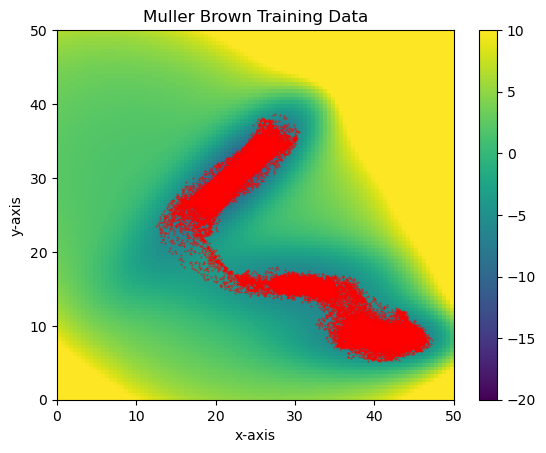

In [38]:
# visualize_mb_data(train_dataset)

In [37]:
from mb_actions import SimpleAction, S2Action, TruncatedAction
from simpleMB import SimpleMB
import random
from ase import units
import math
from contextlib import nullcontext


from torch import nn, Tensor

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper


potential = SimpleMB(device = "cuda",n_in=2)


# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
        
        self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
        self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
    

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

class MBFlowMatchingModel(torch.nn.Module):
    def __init__(self, mlp, num_steps, device):
        super(MBFlowMatchingModel, self).__init__()
        self.device = device
        self.num_steps = 20
        
        self.mlp = mlp
        self.input_dim = mlp.input_dim

        self.dt = 1.0 / num_steps
        self.path = AffineProbPath(scheduler=CondOTScheduler())

    
    def forward(self, x, t):
        return self.mlp(x, t)

    def scaling_factor(self, t):
        scaling_factor = - units.kB * 700 / self.sqrt_one_minus_alphas_cumprod[t]
        return scaling_factor

    def force_func(self, x, t):
        noise_pred = self.forward(x, t)
        # TODO: revisit in light of normalization
        force = self.path.velocity_to_epsilon(noise_pred, x, t)
        return -1*force
    
    def laplacian_func(self, x, t):
        hessian_fn = torch.func.jacrev(self.force_func, argnums = 0)
        hessian = hessian_fn(x, t) # shape of [P x 2 x P x 2]
        indices = torch.arange(x.shape[0])
        laplace = torch.vmap(torch.diag)(hessian[indices, :, indices, :])
        return laplace
    
    def forward_flow(self, x, t, z=None):
        """
        Forward "flow" step:
        Given a data sample x and a time t in [0,1], produce x_t by linear interpolation with a Gaussian sample z.
        
        NOTE: we are actually interpolating between a gaussian shifted and scaled by
        data stats. We do the scaling here and assume z is sample
        This mirrors the forward diffusion in the flow matching context.
        """
        if z is None:
            z = torch.randn_like(x)  # Gaussian noise same shape as x
            
        # z = z * self.mlp.std.reshape((1,-1)) + self.mlp.mean.reshape((1,-1))  # scale and shift noise
        # convert time to be in (0,1)
        t = t / self.num_steps
        x_t = (1 - t)*z + t*x
        return x_t

    @torch.no_grad 
    def sample_from_t(self, x_t, start_time=0):
        """
        Given samples x_t at time start_time, integrate forward to end_time using Euler's method.
        """
    
        solver = ODESolver(velocity_model=self.mlp)  # create an ODESolver class
        return solver.sample(time_grid=torch.linspace(0,1,10), x_init=x_t, method='midpoint', step_size=self.dt, return_intermediates=False) 

    @torch.no_grad
    def sample(self, num_samples):
        """
        Start from Gaussian noise at t=0 and integrate to t=1.
        """
        x_0 = torch.randn((num_samples, self.input_dim), device=self.device)
        # x_0 = x_0 * self.mlp.std.reshape((1,-1)) + self.mlp.mean.reshape((1,-1))
        return self.sample_from_t(x_0)
        
    @torch.no_grad
    def reconstruct(self, x, latent_time):
        """Forward diffusion of samples x to t = t and then sample from t to reconstruct x."""
        # Make sure x is normalized
        assert torch.all(torch.logical_and(x >= -5, x <= 5)), "x must be normalized"
        if isinstance(latent_time, torch.Tensor):
            latent_time = latent_time.item()
        if round(latent_time) != latent_time:
            latent_time = round(latent_time)
        
        with torch.no_grad():
            noised_x = self.forward_flow(x, latent_time, torch.randn_like(x).to(self.device))
            return self.sample_from_t(noised_x, latent_time)
    
    def interpolation(self, x1, x2, path_length, latent_time, num_paths = 10, interpolation_fn = torch.lerp):
        """"
        Encode the two points into latent space, linearly or spherically interpolate, and decode.
        Note: Expects x1 and x2 to be normalized.
        """
        # Make sure x1 and x2 are normalized
        assert torch.all(torch.logical_and(x1 >= -5, x1 <= 5)), "x1 must be normalized"
        assert torch.all(torch.logical_and(x2 >= -5, x2 <= 5)), "x2 must be normalized"
        if isinstance(latent_time, torch.Tensor):
            latent_time = latent_time.item()
        
        if round(latent_time) != latent_time:
            latent_time = round(latent_time)

        x1 = x1.repeat(num_paths, 1)
        x2 = x2.repeat(num_paths, 1)
        original_x1 = x1.clone()
        original_x2 = x2.clone()

        with torch.no_grad():
            noise_1 = torch.randn_like(x1).to(self.device)
            noise_2 = torch.randn_like(x2).to(self.device)
            noised_x1 = self.forward_flow(x1, latent_time, noise_1)
            noised_x2 = self.forward_flow(x2, latent_time, noise_2)

        # linear interpolation of noised_x1 and noised_x2
        
        noised_xs = torch.stack([interpolation_fn(noised_x1.cpu(), noised_x2.cpu(), alpha) for alpha in torch.linspace(0, 1, path_length)])
        noised_xs = noised_xs.permute((1, 0, 2)).to(self.device)
    
        # decode
        xs = self.sample_from_t(noised_xs.reshape(-1, 2), latent_time)

        xs = xs.reshape(num_paths, path_length, 2)
        xs = xs.clone().detach()

        # reset the endpoints
        xs[:, 0], xs[:, -1] = original_x1, original_x2
        
        return xs
        
    def om_interpolation(self, x1, x2, path_length, latent_time, num_paths = 10, action_cls = TruncatedAction, initial_guess_fn = torch.lerp, om_steps = 100, lr = 2e-1, anneal = False, temperature = 1.0, subsample_points_percent=None, subsample_dimensions_percent=None, D=0.1, dt=0.01, gamma=0.01):
        """"
        Encode the two points into latent space, linearly interpolate, and decode
        Note: Expects x1 and x2 to be normalized.
        """
        # Make sure x1 and x2 are normalized
        assert torch.all(torch.logical_and(x1 >= -5, x1 <= 5)), "x1 must be normalized"
        assert torch.all(torch.logical_and(x2 >= -5, x2 <= 5)), "x2 must be normalized"
        # if isinstance(latent_time, torch.Tensor):
        #     latent_time = latent_time.item()
        # if round(latent_time) != latent_time:
        #     latent_time = round(latent_time)

        if anneal:
            om_steps = self.num_steps # to make sure we anneal from T to 0

        x1 = x1.repeat(num_paths, 1)
        x2 = x2.repeat(num_paths, 1)

        original_x1 = x1.clone()
        original_x2 = x2.clone()
        # with torch.no_grad():
        #     noise_1 = torch.randn_like(x1).to(self.device)
        #     noise_2 = torch.randn_like(x2).to(self.device)
            
        #     noised_x1 = self.forward_flow(x1, latent_time, noise_1)
        #     noised_x2 = self.forward_flow(x2, latent_time, noise_2)
            
        noised_x1 = original_x1
        noised_x2 = original_x2
            
        # linear interpolation of noised_x1 and noised_x2
        noised_xs = torch.stack([initial_guess_fn(noised_x1.cpu(), noised_x2.cpu(), alpha) for alpha in torch.linspace(0, 1, path_length)])
        noised_xs = noised_xs.permute((1, 0, 2)).to(self.device)  # shape of [num_paths x path_length x 2]
        optimizer = torch.optim.SGD([noised_xs], lr = lr)

        pbar = tqdm(range(om_steps))
        paths = []
        actions = []
        grad_ratios = []

        with torch.enable_grad():
            noised_xs.requires_grad = True
            # Optimization of path using OM action
            for i in pbar:
                if anneal:
                    diff_time = self.num_steps - i - 1 # anneal the time from T to 0
                else:
                    diff_time = latent_time
                
                def temp_force_func(x):
                    # test function to use true force magnitude and predicted force direction
                    force = self.force_func((x - mean) / std, diff_time)
                    force = force / torch.norm(force, dim = -1).unsqueeze(-1)
                    force *= torch.norm(potential.force_func(x)[1], dim = -1).unsqueeze(-1)
                    return force
                
                # force_func = temp_force_func
                force_func = lambda x: self.force_func(x, torch.tensor([diff_time], device="cuda"))
                # force_func = lambda x: potential.force_func(x)[1]
                laplace = lambda x: self.laplacian_func(x, torch.tensor([diff_time], device="cuda"))
                action_func = action_cls(force_func = force_func, laplace_func=laplace, dt = dt, gamma = gamma, D = D) # TODO: figure out dt, gamma, D
            
                action = torch.vmap(action_func, randomness="different")(noised_xs).mean()
                actions.append(action.item())

                pred_force = force_func(noised_xs.reshape(-1, 2))
                true_force = potential.force_func(noised_xs.reshape(-1, 2))[1]
                # if diff_time == 0:
                #     print("Cosine similarity", F.cosine_similarity(pred_force, true_force).mean().item())

                optimizer.zero_grad()
                grads, = torch.autograd.grad(action, noised_xs)
            
                with torch.no_grad():
                    
                    # grads shape is [num_paths, path_length, 2]
                    # Set endpoint grads to 0
                    grads[:, 0], grads[:, -1] = torch.zeros(2).to(self.device), torch.zeros(2).to(self.device)
                    
    
                    if subsample_points_percent is not None:
                        num_points = path_length - int(subsample_points_percent * path_length)
                        bad_idx = torch.randperm(path_length)[:num_points]
                        grads[:, bad_idx] = 0
                    
                    if subsample_dimensions_percent is not None:
                        rand = torch.rand_like(grads)
                        keep_idx = rand < subsample_dimensions_percent
                        grads = grads * keep_idx


                    noised_xs.grad = grads
                    optimizer.step()
                    # scheduler.step()
                    # scheduler.step(action)

                pbar.set_description(f"OM Action: {action.item()}")
                # compute ratio of grads to noised_xs:
                grad_ratio= lr * torch.norm(grads, dim = -1) / torch.norm(noised_xs, dim = -1)
                grad_ratios.append(grad_ratio.mean().item())
                # pbar.set_description(f"Grad Update Ratio: {grad_ratio.mean().item() * lr}")
                # pbar.set_description(f"Force Norm: {force_func(noised_xs.reshape(-1, 2)).norm(dim = -1).mean().item()}")
                if i % int(om_steps / 10) == 0:
                    with torch.no_grad():
                        # decoded_path = self.sample_from_t(noised_xs.reshape(-1, 2), latent_time)
                        decoded_path = noised_xs.reshape(num_paths, path_length, 2)
                        paths.append(decoded_path.detach())

        # decode along optimized path
        with torch.no_grad():
            # xs = self.sample_from_t(noised_xs.reshape(-1, 2), latent_time)
            xs = noised_xs
            xs = xs.reshape(num_paths, path_length, 2)
            xs = xs.clone().detach()

            # reset the endpoints
            xs[:, 0], xs[:, -1] = original_x1, original_x2

            return xs, paths, actions, grad_ratios

In [5]:
import wandb
wandb.require("core")

def train_mb_diffusion_alt(train_dataset, test_dataset, model, n_epochs, device, lr, batch_size, force_supervision_level = None):
    """

    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch
    - a numpy array of size (9, 2000, 2) of samples drawn from your model.
      Draw 2000 samples for each of 9 different number of diffusion sampling steps
      of evenly logarithmically spaced integers 1 to 512
      hint: np.power(2, np.linspace(0, 9, 9)).astype(int)
    """

    """ YOUR CODE HERE """
    PI = torch.tensor([np.pi]).to(device)
    optimizer = optim.Adam(model.mlp.parameters(), lr = lr)

    # instantiate an affine path object
    path = AffineProbPath(scheduler=CondOTScheduler())
    #normalize training data
    # train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
    tensor_data = train_dataset.all_pos.reshape(-1,3)[:,:2]
    tensor_dataset = torch.from_numpy(tensor_data).float()
    tensor_dataset = TensorDataset(tensor_dataset) 
    train_dataloader = DataLoader(tensor_dataset, batch_size=batch_size)
    
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False)
    
    mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
    std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
    # train_data = (train_data - train_mean) / train_std
    # test_data = (test_data - train_mean) / train_std
    
    train_losses = []
    test_losses = []
    for i in tqdm(range(n_epochs)):
        model.train()
        # print(f"Epoch {e}")
        with torch.enable_grad():
        
            for x in train_dataloader:
                optimizer.zero_grad()
                x_1 = x[0].to(device)
                
                x_1 = (x_1 - mean) / std

                x_0 = torch.randn_like(x_1).to(device)

                # sample time (user's responsibility)
                t = torch.rand(x_1.shape[0]).to(device) 
                

                # sample probability path
                path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
                
                u_t = path_sample.dx_t 

                # flow matching l2 loss
                loss = torch.pow( model(path_sample.x_t,path_sample.t) - u_t, 2).mean() 

                # optimizer step
                loss.backward() # backward
                optimizer.step() # update
                
                train_losses.append(loss.unsqueeze(-1))
                

        model.eval()
        tls = []
        with torch.no_grad():
            for x, force in test_dataloader:
                
                x = x.to(device)
                force = force.to(device)
                x = (x - mean) / std
                
                #sample diffusion timestep (uniform between 0 and num_steps exclusive)
                t = torch.randint(0, model.num_steps, (x.shape[0],1)).to(x.device)

                # sample noise and diffuse
                noise = torch.randn_like(x)
                noised_x = model.forward_flow(x, t, noise)
                
                #forward pass
                pred_noise = model(noised_x, t).to(torch.float32)
                #compute loss and optimize
                loss = F.mse_loss(pred_noise, noise)
                tls.append(loss.unsqueeze(-1))

                # for logging force loss
                t = torch.ones_like(t)
                pred_force = model.force_func(x, t)
                log_force_mse = F.mse_loss(pred_force, force)
                log_force_cosine = F.cosine_similarity(pred_force, force).mean()

            test_loss = torch.cat(tls).sum(0) / len(tls)
            test_losses.append(test_loss.unsqueeze(-1))
            if not DISABLE_WANDB_LOGGING: 
                wandb.log({"test_loss": test_loss, "test_force_mse": log_force_mse, "test_force_cosine": log_force_cosine})
            # print("Test loss: ", test_losses[-1].item())
            
    return get_numpy(torch.cat(train_losses)), get_numpy(torch.cat(test_losses))

In [ ]:
from src.utils import validate_git_status

# Training config
config = {
    "n_epochs": 50,
    "batch_size": 4096,
    "num_steps": 20,
    "lr": 0.001,
    "force_supervision_level": None,
    "mlp_hidden_dim": 512,
    "conservative": False
}

# debugging args
DISABLE_GIT_CHECK = True
DISABLE_WANDB_LOGGING = True

if not DISABLE_GIT_CHECK:
    validate_git_status()

device = torch.device(torch.cuda.current_device())
mlp = MLP(input_dim=2, time_dim=1, hidden_dim=config["mlp_hidden_dim"]).to(device) 
model = MBFlowMatchingModel(mlp, num_steps = config["num_steps"], device = device).to(device).to(torch.float32)

if not DISABLE_WANDB_LOGGING:   
    wandb.login()
    wandb.init(project="mb-diffusion-model", config=config, name="mb_diffusion")
    wandb.watch(mlp)

# Train model
train_losses, test_losses = train_mb_diffusion_alt(train_dataset, test_dataset, model, n_epochs = config["n_epochs"], \
                                                lr = config["lr"], batch_size = config["batch_size"], device = device, \
                                                force_supervision_level = config["force_supervision_level"])

# save model checkpoint (locally and on wandb)
torch.save(mlp.state_dict(), "mb_flowmatching_model.pt")
if not DISABLE_WANDB_LOGGING:
    wandb.save('mb_flowmatching_model.pt')
    wandb.finish()

/tmp/ipykernel_414301/540584679.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_414301/540584679.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)


In [ ]:
del mlp, model

/tmp/ipykernel_414301/540584679.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_414301/540584679.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
/tmp/ipykernel_414301/3119400671.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more detai

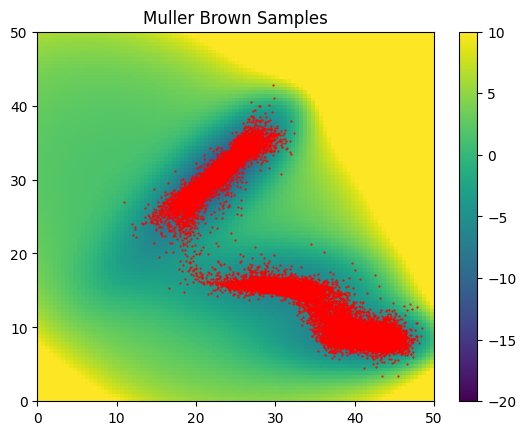

In [7]:
# Unconditional samples from the model
device = torch.device(torch.cuda.current_device())
mlp = MLP(input_dim=2, time_dim=1, hidden_dim=config["mlp_hidden_dim"]).to(device) 
mlp.load_state_dict(torch.load("mb_flowmatching_model.pt"))
model = MBFlowMatchingModel(mlp, num_steps = config["num_steps"], device = device).to(device).to(torch.float32)
all_samples = model.sample(100000)
mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
all_samples = all_samples*std + mean
all_samples = get_numpy(all_samples)
plot_samples(all_samples, title="Muller Brown Samples") 

In [50]:
del mlp, model

/tmp/ipykernel_414301/1099971423.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_414301/1099971423.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
/tmp/ipykernel_414301/1162389838.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more det

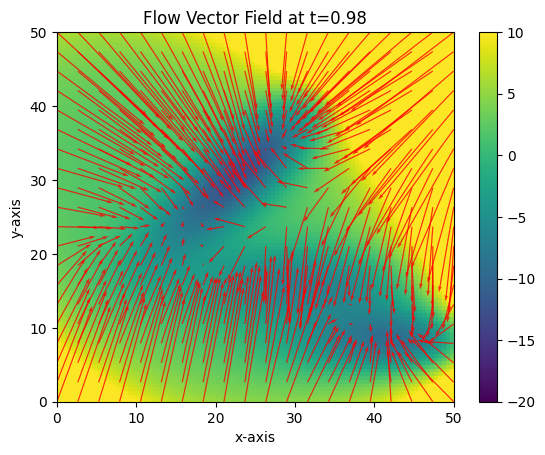

In [14]:
# Unconditional samples from the model
device = torch.device(torch.cuda.current_device())
mlp = MLP(input_dim=2, time_dim=1, hidden_dim=config["mlp_hidden_dim"]).to(device) 
mlp.load_state_dict(torch.load("mb_flowmatching_model.pt"))
model = MBFlowMatchingModel(mlp, num_steps = config["num_steps"], device = device).to(device).to(torch.float32)
mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
std = torch.tensor(train_dataset.std).to(device).to(torch.float32)

path = AffineProbPath(scheduler=CondOTScheduler())
score_conversion = lambda x, t: path.velocity_to_epsilon(model(x, t), x, t)

# mean = torch.tensor([0,0]).cuda()
# std = torch.tensor([1,1]).cuda()
# Custom limits for arrows
xmin, xmax = None, None
ymin, ymax = None, None
# Plot vector field
t = 0.98 # Specify the time step to condition on
plot_flow_vector_field(
    model, 
    calculator, 
    t, 
    grid_width=20, 
    title=f"Flow Vector Field at t={t}",
    arrow_scale=0.2, 
    arrow_width=0.003,
    mean=mean,
    std=std,
    xmin=xmin,
    xmax=xmax,
    ymin=ymin,
    ymax=ymax
)

/tmp/ipykernel_412407/2978492900.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_412407/2978492900.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
/tmp/ipykernel_412407/3819646229.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more det

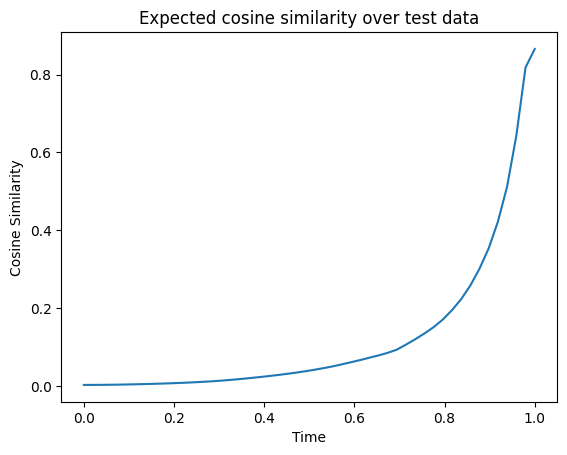

In [12]:
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

# Unconditional samples from the model
device = torch.device(torch.cuda.current_device())
mlp = MLP(input_dim=2, time_dim=1, hidden_dim=config["mlp_hidden_dim"]).to(device) 
mlp.load_state_dict(torch.load("mb_flowmatching_model.pt"))
model = MBFlowMatchingModel(mlp, num_steps = config["num_steps"], device = device).to(device).to(torch.float32)
mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
std = torch.tensor(train_dataset.std).to(device).to(torch.float32)

ts = np.linspace(0, 1, 50)
cosine_sims = []
for t in ts:
    with torch.no_grad():
        x, force = next(iter(test_dataloader))
        # compute force using model
        x = x.to("cuda")
        x = (x - mean) / std
        force_pred = model.force_func(x, torch.tensor([t], device="cuda"))
        # inner prod btwn true and pref
        mean_ip = F.cosine_similarity(force.to("cuda"), force_pred, dim=1).mean().item()
        cosine_sims.append(mean_ip)
        
plt.xlabel("Time")
plt.ylabel("Cosine Similarity")
plt.title("Expected cosine similarity over test data")
plt.plot(ts, cosine_sims)

/tmp/ipykernel_2095389/3799383736.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_2095389/3799383736.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00,  9.49it/s]


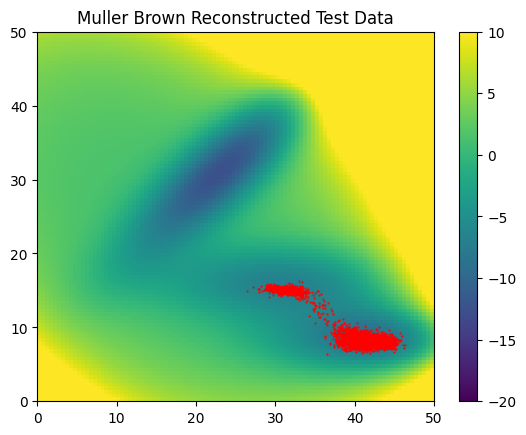

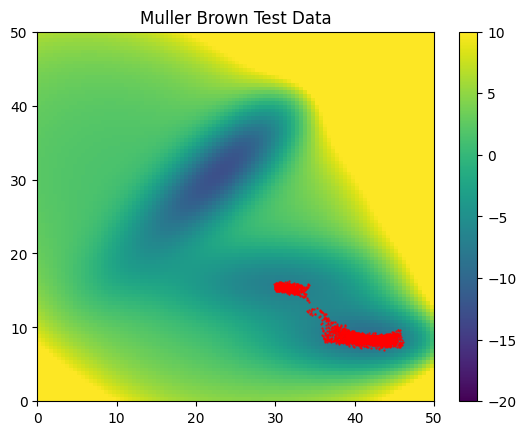

In [ ]:
# Reconstruction of test data (first batch of dataloader)
latent_time = 25 # diffusion steps for reconstruction (larger means more diverse samples)
device = torch.device(torch.cuda.current_device())
mlp = MLP(3, 256, 2, device).to(device).to(torch.float32)
mlp.load_state_dict(torch.load("/home/sanjeevr/om-diffusion/wandb/run-20240724_170617-6puhaob8/files/mb_diffusion_model.pt"))
model = MBDiffusionModel(mlp, num_steps = 256, device = device).to(device).to(torch.float32)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = 5000, shuffle = False)
reconstructed_xs = []
xs = []
for x, _ in tqdm(test_dataloader):
    x = x.to(device)
    # take a subset of the data so that we can distinguish the latent times for reconstruction
    mask = torch.logical_and(x[:, 0] > 30, x[:, 1] < 20)
    x = x[mask]
    x = (x - mean) / std
    reconstructed_x = model.reconstruct(x, latent_time, temperature = 1.0)
    x = model.reconstruct(x, 0, temperature = 1.0) # perfect reconstruction
    reconstructed_x = reconstructed_x * std + mean
    x = x * std + mean
    reconstructed_xs.append(reconstructed_x)
    xs.append(x)

reconstructed_xs = torch.cat(reconstructed_xs)
xs = torch.cat(xs)

plot_samples(get_numpy(reconstructed_xs), title = "Muller Brown Reconstructed Test Data")
plot_samples(get_numpy(xs), title = "Muller Brown Test Data")

In [42]:
np.save("mb_mean.npy", get_numpy(mean))
np.save("mb_std.npy", get_numpy(std))

In [15]:
# Define common args for interpolation experiments
latent_times = torch.linspace(0, 1, 9).to(torch.long).to(device)

# start and end points for interpolation - different from basins to ensure we're not just i.i.d sampling
x1 = torch.Tensor([[26, 34]]).to(device)
x2 = torch.Tensor([[31, 15]]).to(device)

# Normalize the points
x1 = (x1 - mean) / std
x2 = (x2 - mean) / std


/tmp/ipykernel_302773/739505846.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_302773/739505846.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
/tmp/ipykernel_302773/1241563545.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


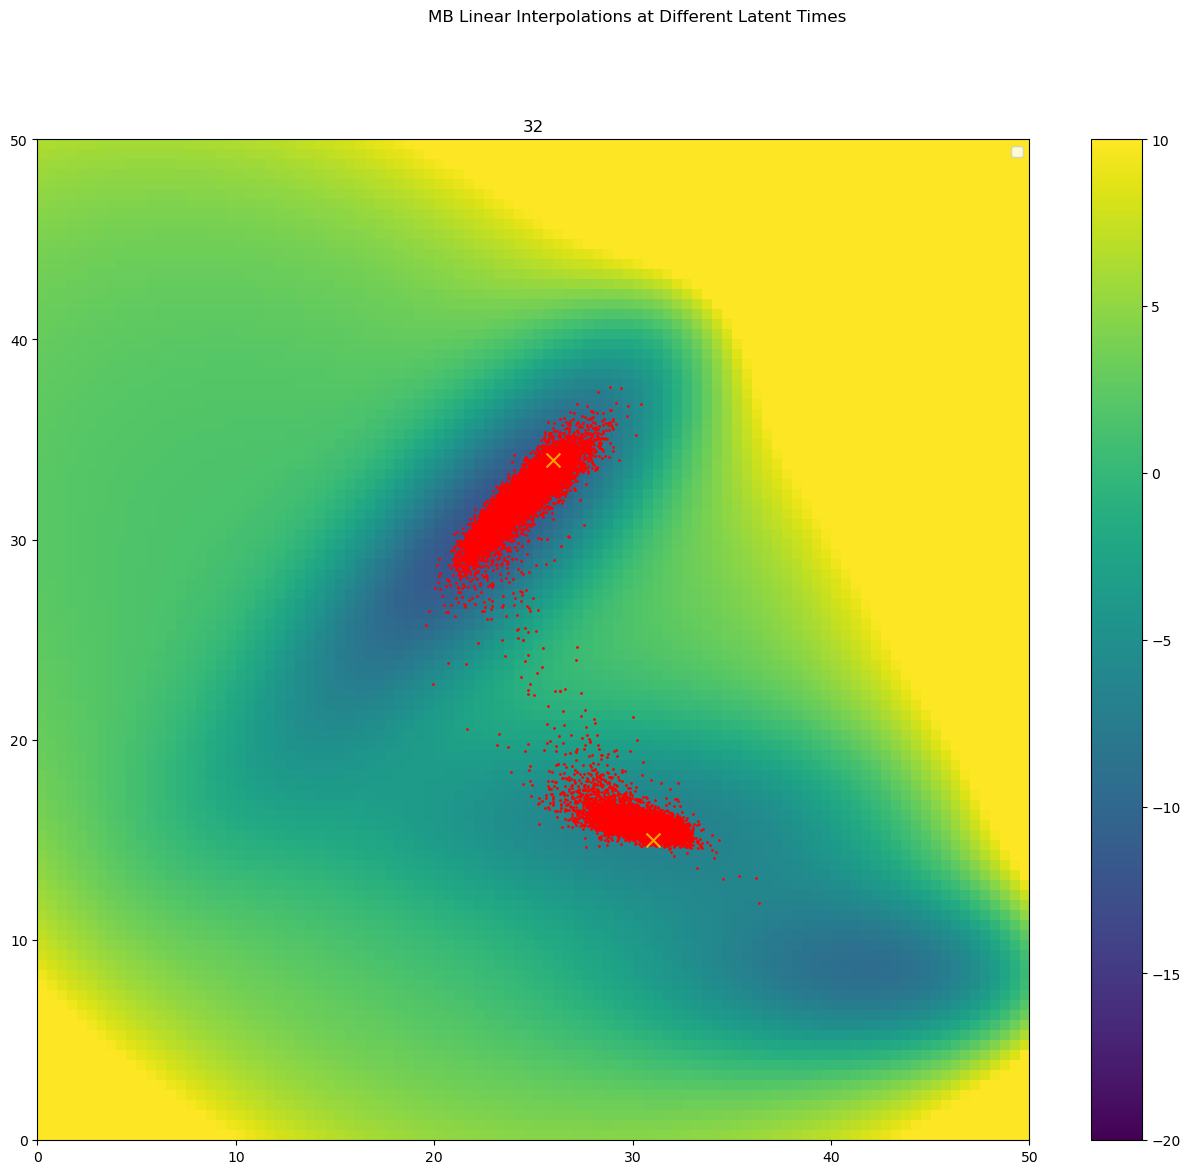

In [44]:
# linear interpolation in diffusion space
mlp = MLP(3, 256, 2, device, act = F.gelu).to(device).to(torch.float32)
mlp.load_state_dict(torch.load("/data/shared/models/om/mb_diffusion_model_gelu.pt"))
model = MBDiffusionModel(mlp, num_steps = 256, device = device).to(device).to(torch.float32)
samples = torch.stack([model.interpolation(x1, x2, path_length=50, num_paths = 1000, latent_time=time) for time in latent_times])
samples = samples*std + mean
save_multi_scatter_2d(get_numpy(samples.reshape(len(latent_times), -1, 2)), latent_times, title = "MB Linear Interpolations at Different Latent Times")

/tmp/ipykernel_302773/739505846.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_302773/739505846.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
/tmp/ipykernel_302773/1241563545.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


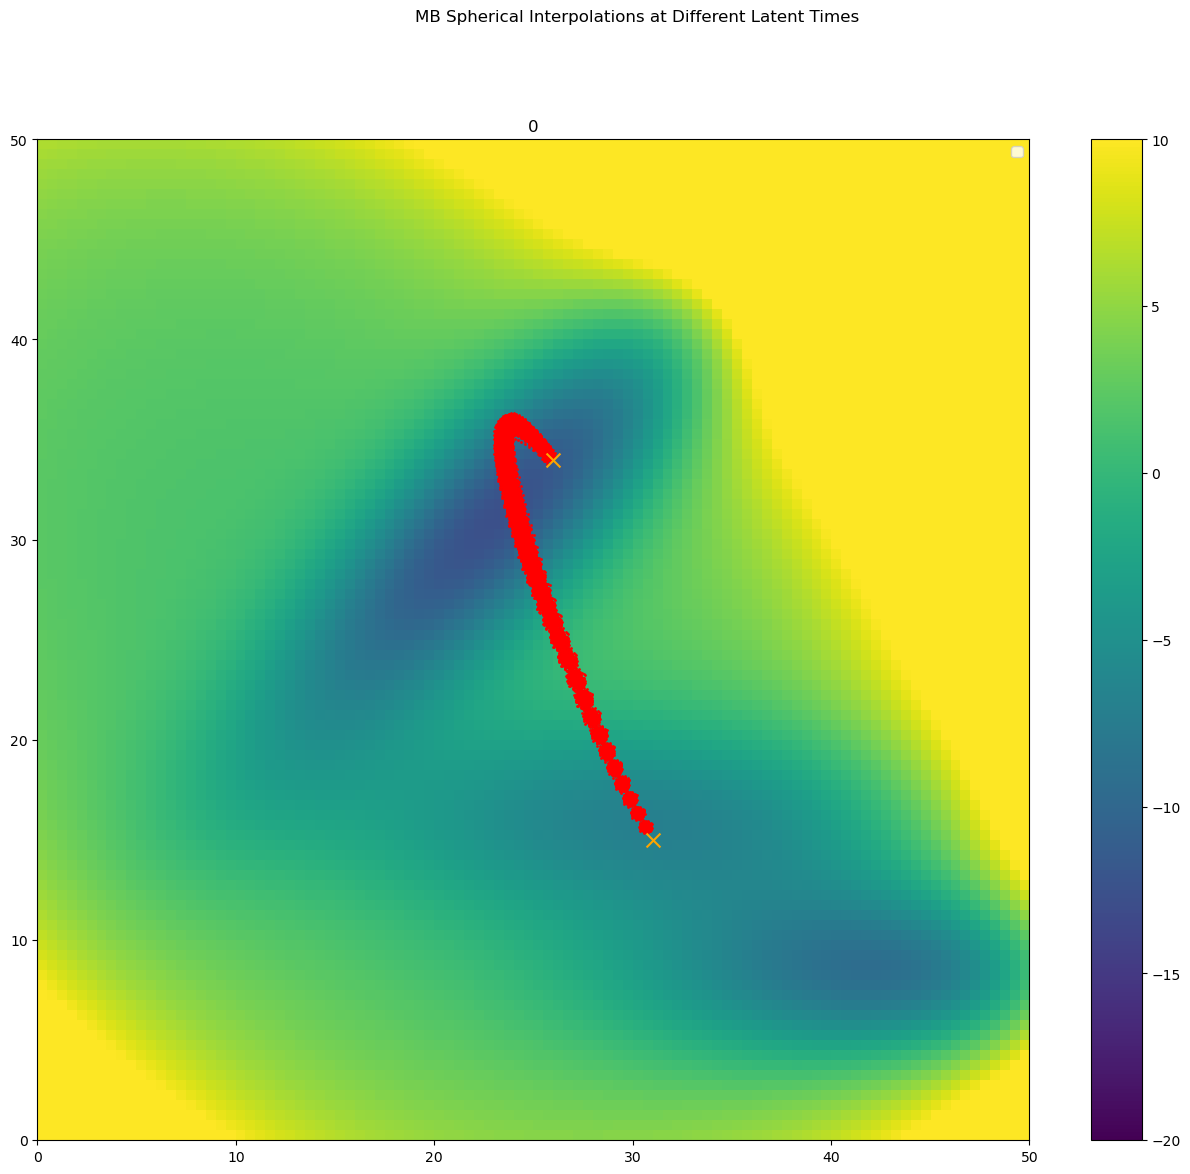

In [22]:
# spherical interpolation in diffusion space
mlp = MLP(3, 256, 2, device, act = F.gelu).to(device).to(torch.float32)
mlp.load_state_dict(torch.load("/data/shared/models/om/mb_diffusion_model_gelu.pt"))
model = MBDiffusionModel(mlp, num_steps = 256, device = device).to(device).to(torch.float32)
samples = torch.stack([model.interpolation(x1, x2, path_length=50, num_paths = 1000, latent_time=time, interpolation_fn=slerp) for time in latent_times])
samples = samples*std + mean
save_multi_scatter_2d(get_numpy(samples.reshape(len(latent_times), -1, 2)), latent_times, title = "MB Spherical Interpolations at Different Latent Times")

/tmp/ipykernel_414301/3269379929.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_414301/3269379929.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
/tmp/ipykernel_414301/3805645409.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more det

OM Action: 1.0420399904251099: 100%|██████████| 1000/1000 [00:06<00:00, 165.65it/s]


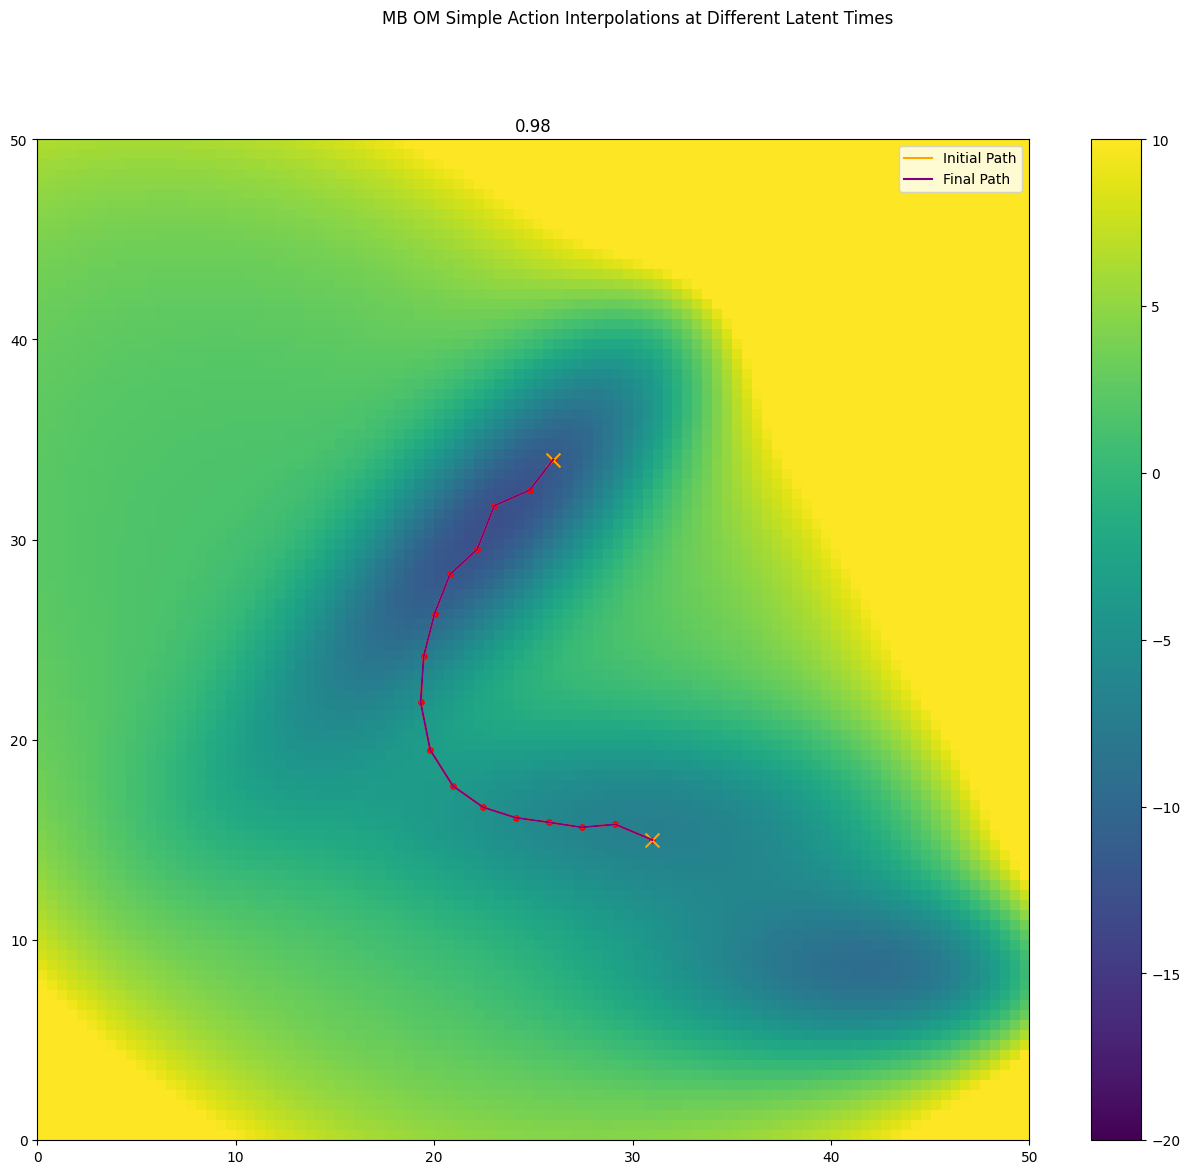

In [43]:
# om interpolation in diffusion space - SimpleAction
latent_times = torch.linspace(0, 64, 9).to(torch.long).to(device)
latent_times = [0.98]
mlp = MLP(input_dim=2, time_dim=1, hidden_dim=config["mlp_hidden_dim"]).to(device) 
mlp.load_state_dict(torch.load("mb_flowmatching_model.pt"))
model = MBFlowMatchingModel(mlp, num_steps = 20, device = device).to(device).to(torch.float32)
out = [model.om_interpolation(x1, x2, path_length=16, num_paths = 1, latent_time=time, om_steps = 1000, lr = 1e-1, subsample_points_percent=None, subsample_dimensions_percent=None, dt=0.0023) for time in latent_times] 

samples, paths, actions, grad_ratios = zip(*out)
samples = torch.stack(samples) # [9 x num_paths x path_length x 2]
samples = samples*std + mean
samples = get_numpy(samples.reshape(len(latent_times), -1, 2))

paths = torch.stack([torch.stack(p) for p in paths]) #[9 x om_steps/save_every x num_paths x path_length x 2]
paths = paths*std + mean

paths = get_numpy(paths.mean(dim = 2)) # average over paths

save_multi_scatter_2d(samples, latent_times, title = "MB OM Simple Action Interpolations at Different Latent Times", paths = paths)

/tmp/ipykernel_705866/209862594.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_705866/209862594.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
OM Action: 5.630046844482422:   0%|          | 4/1000 [00:00<00:28, 35.03it/s]

OM Action: 0.028691839426755905: 100%|██████████| 1000/1000 [00:28<00:00, 35.16it/s]


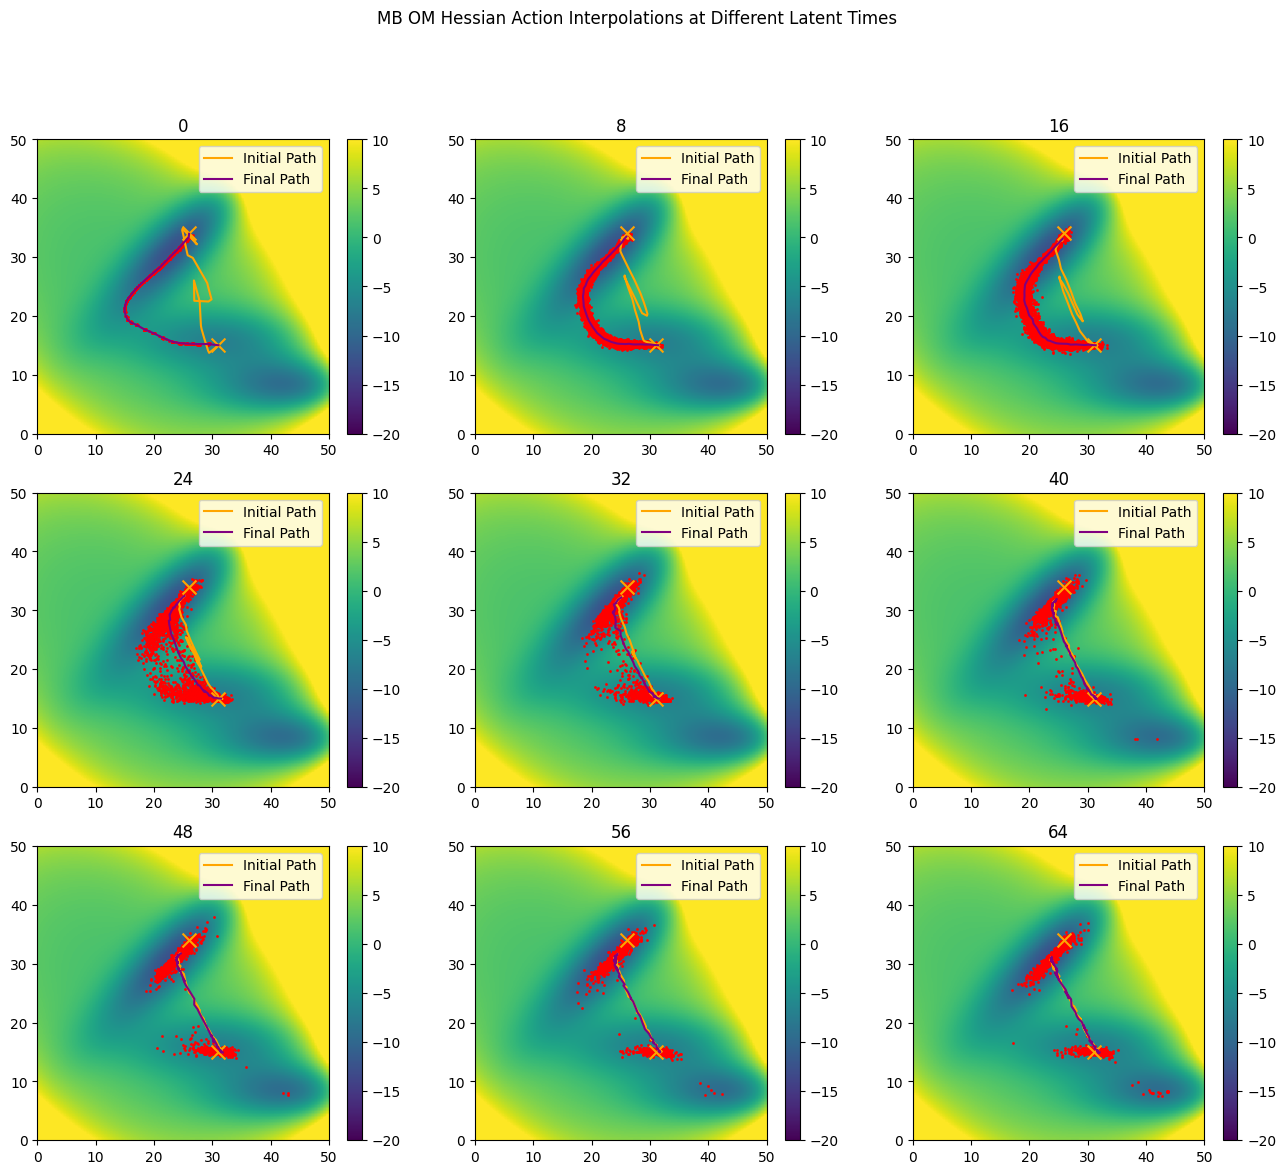

In [46]:
#  om interpolation in diffusion space - S2Action
mlp = MLP(3, 256, 2, device).to(device).to(torch.float32)
mlp.load_state_dict(torch.load("mb_diffusion_model.pt"))
model = MBDiffusionModel(mlp, num_steps = 256, device = device).to(device).to(torch.float32)
out = [model.om_interpolation(x1, x2, action_cls = S2Action, path_length=50, num_paths = 100, latent_time=time, om_steps = 1000, lr = 2e-1) for time in latent_times] 
samples, paths, actions, grad_ratios = zip(*out) # TODO: plot evolution of paths during optimization
samples = torch.stack(samples) # [9 x num_paths x path_length x 2]
samples = samples*std + mean
samples = get_numpy(samples.reshape(len(latent_times), -1, 2))

paths = torch.stack([torch.stack(p) for p in paths]) #[9 x om_steps/save_every x num_paths x path_length x 2]
paths = paths*std + mean

paths = get_numpy(paths.mean(dim = 2)) # average over paths

save_multi_scatter_2d(samples, latent_times, title = "MB OM Hessian Action Interpolations at Different Latent Times", paths = paths)

/tmp/ipykernel_302773/1392939724.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_302773/1392939724.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
OM Action: -16.11988067626953: 100%|██████████| 1000/1000 [00:11<00:00, 89.21it/s]


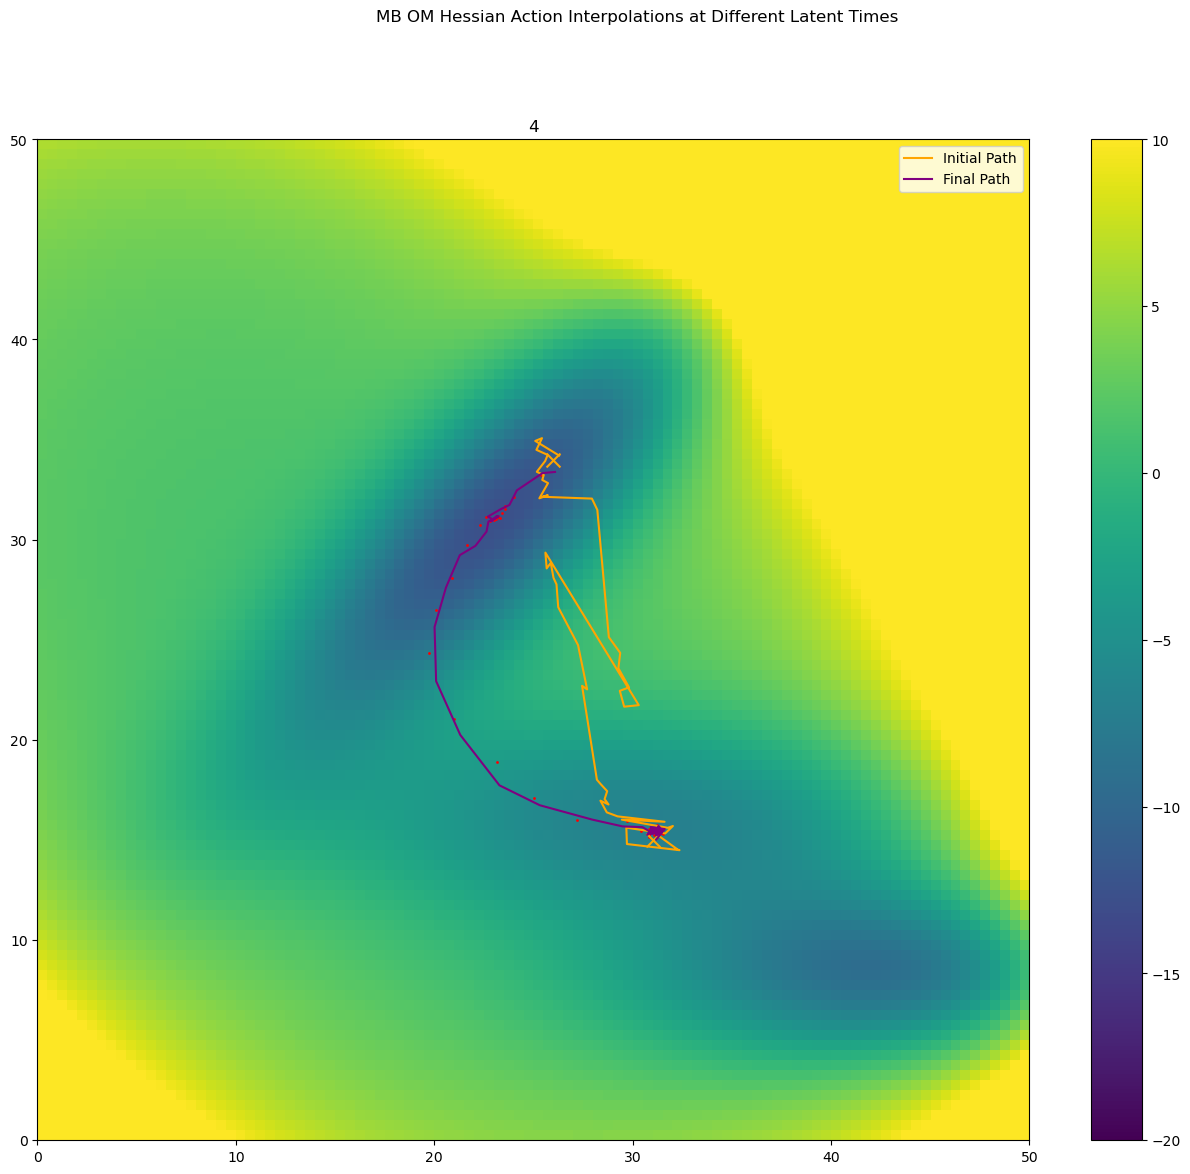

In [63]:
from mb_actions import HutchinsonAction
#  om interpolation in diffusion space - S2Action
mlp = MLP(3, 256, 2, device, act=F.gelu).to(device).to(torch.float32)
mlp.load_state_dict(torch.load("/data/shared/models/om/mb_diffusion_model_gelu.pt"))
latent_times = [4]
model = MBDiffusionModel(mlp, num_steps = 256, device = device).to(device).to(torch.float32)
out = [model.om_interpolation(x1, x2, action_cls = HutchinsonAction, path_length=50, num_paths = 1, latent_time=time, om_steps = 1000, lr = 2e-1, D=1, dt=0.01, gamma=0.01) for time in latent_times] 
samples, paths, actions, grad_ratios = zip(*out) # TODO: plot evolution of paths during optimization
samples = torch.stack(samples) # [9 x num_paths x path_length x 2]
samples = samples*std + mean
samples = get_numpy(samples.reshape(len(latent_times), -1, 2))

paths = torch.stack([torch.stack(p) for p in paths]) #[9 x om_steps/save_every x num_paths x path_length x 2]
paths = paths*std + mean

paths = get_numpy(paths.mean(dim = 2)) # average over paths

save_multi_scatter_2d(samples, latent_times, title = "MB OM Hessian Action Interpolations at Different Latent Times", paths = paths)

/tmp/ipykernel_302773/1392939724.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_302773/1392939724.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
OM Action: 0.1651393473148346: 100%|██████████| 1000/1000 [00:06<00:00, 149.17it/s]


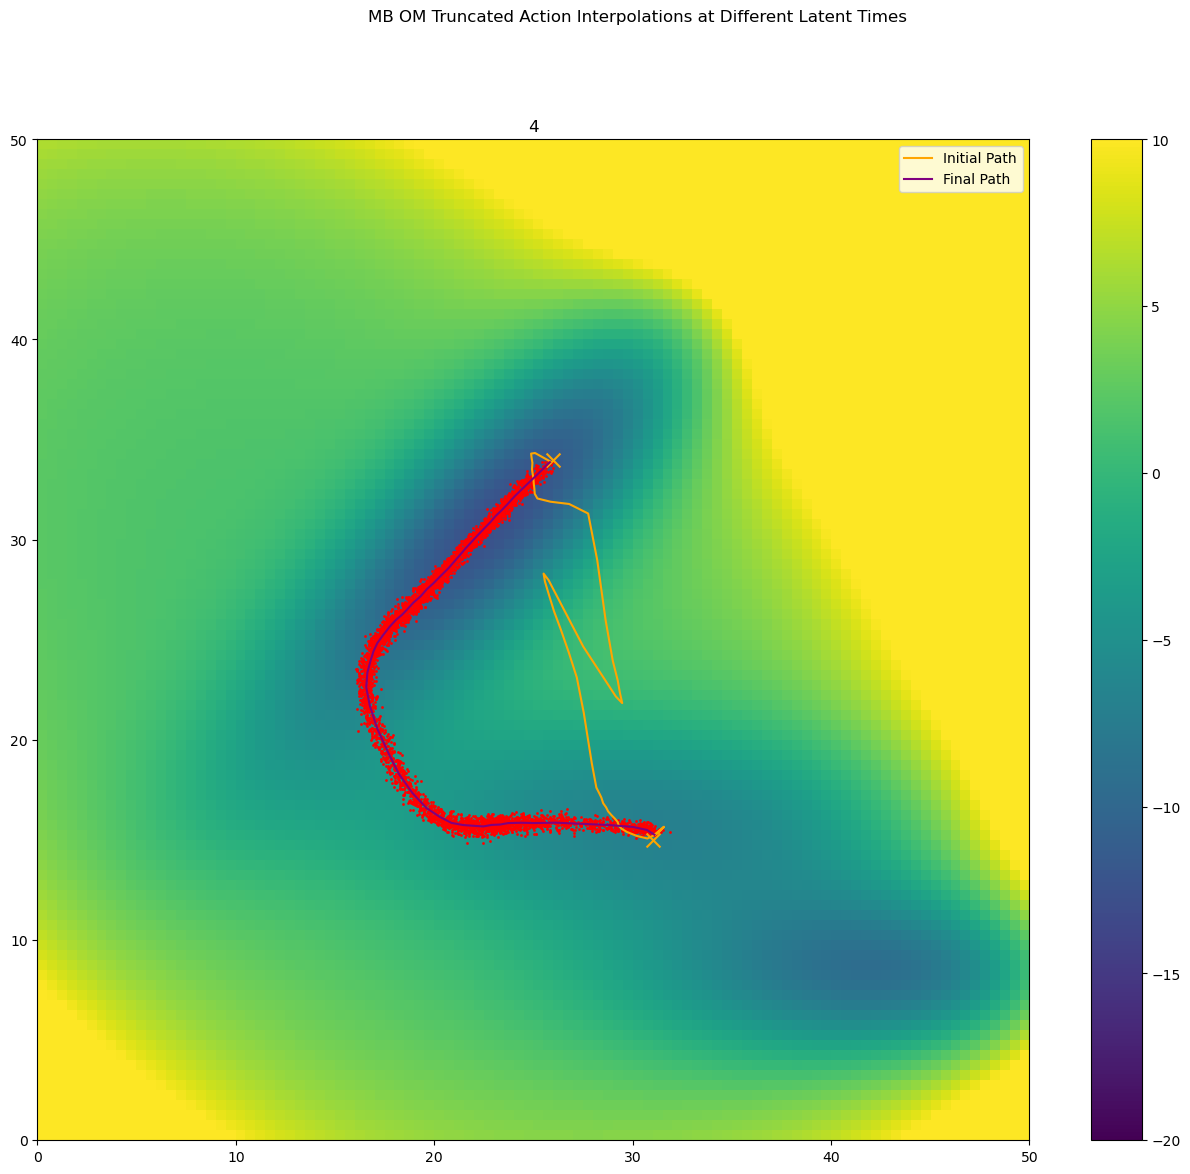

In [64]:
# om interpolation in diffusion space - TruncatedAction
mlp = MLP(3, 256, 2, device, act = F.gelu).to(device).to(torch.float32)
mlp.load_state_dict(torch.load("mb_diffusion_model_gelu.pt"))
model = MBDiffusionModel(mlp, num_steps = 256, device = device).to(device).to(torch.float32)
out = [model.om_interpolation(x1, x2, action_cls = TruncatedAction, path_length=50, num_paths = 100, latent_time=time, om_steps = 1000, lr = 2e-1) for time in latent_times] 
samples, paths, actions, grad_ratios = zip(*out) # TODO: plot evolution of paths during optimization
samples = torch.stack(samples) # [9 x num_paths x path_length x 2]
samples = samples*std + mean
samples = get_numpy(samples.reshape(len(latent_times), -1, 2))

paths = torch.stack([torch.stack(p) for p in paths]) #[9 x om_steps/save_every x num_paths x path_length x 2]
paths = paths*std + mean

paths = get_numpy(paths.mean(dim = 2)) # average over paths

save_multi_scatter_2d(samples, latent_times, title = "MB OM Truncated Action Interpolations at Different Latent Times", paths = paths)

/tmp/ipykernel_2095389/2265395274.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_2095389/2265395274.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
OM Action: 0.6084944009780884:   0%|          | 0/256 [00:00<?, ?it/s]  

OM Action: 5.2958831787109375: 100%|██████████| 256/256 [00:02<00:00, 126.69it/s]  


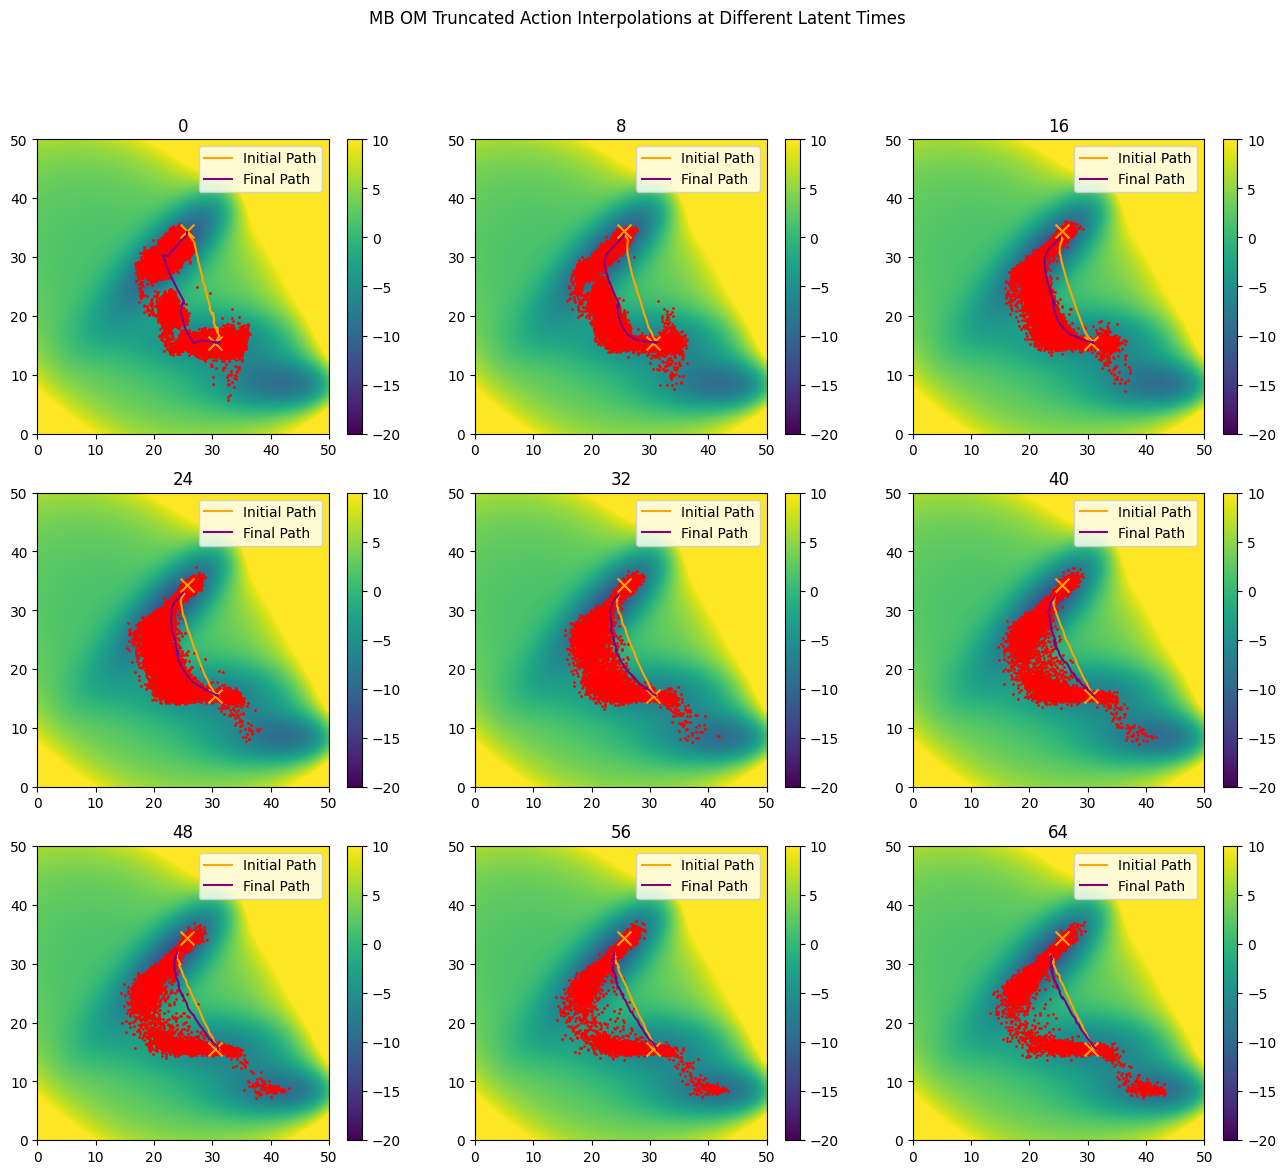

In [95]:
# om interpolation in diffusion space - TruncatedAction - with annealing
mlp = MLP(3, 256, 2, device).to(device).to(torch.float32)
mlp.load_state_dict(torch.load("mb_diffusion_model.pt"))
model = MBDiffusionModel(mlp, num_steps = 256, device = device).to(device).to(torch.float32)
out = [model.om_interpolation(x1, x2, path_length=50, num_paths = 500, latent_time=time, om_steps = 500, anneal = True, lr=2e-1) for time in latent_times] 
samples, paths, actions, grad_ratios = zip(*out) # TODO: plot evolution of paths during optimization
samples = torch.stack(samples) # [9 x num_paths x path_length x 2]
samples = samples*std + mean
samples = get_numpy(samples.reshape(len(latent_times), -1, 2))

paths = torch.stack([torch.stack(p) for p in paths]) #[9 x om_steps/save_every x num_paths x path_length x 2]
paths = paths*std + mean

paths = get_numpy(paths.mean(dim = 2)) # average over paths

save_multi_scatter_2d(samples, latent_times, title = "MB OM Truncated Action Interpolations at Different Latent Times", paths = paths)

In [74]:
np.linspace(0.8, 1, 10)

array([0.8       , 0.82222222, 0.84444444, 0.86666667, 0.88888889,
       0.91111111, 0.93333333, 0.95555556, 0.97777778, 1.        ])

/tmp/ipykernel_303715/2352856690.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mlp.load_state_dict(torch.load("mb_flowmatching_model.pt"))


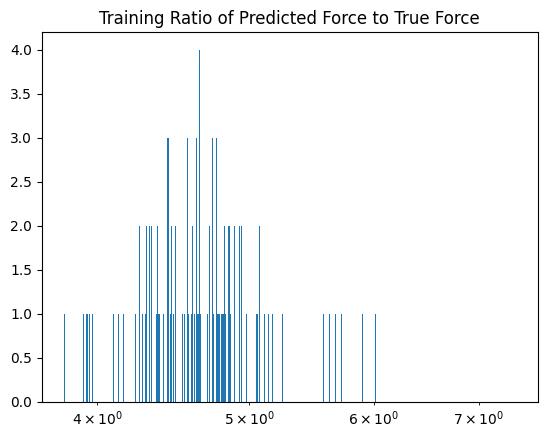

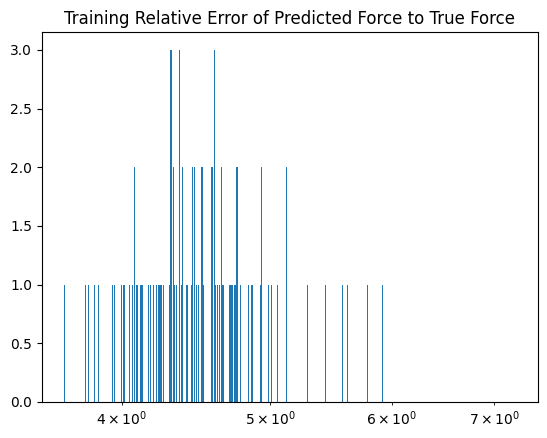

In [78]:
# Evaluate how well the diffusion model matches the true forces

# Loop over the training dataset
device = torch.device(torch.cuda.current_device())
mlp = MLP(input_dim=2, time_dim=1, hidden_dim=config["mlp_hidden_dim"]).to(device) 
mlp.load_state_dict(torch.load("mb_flowmatching_model.pt"))
model = MBFlowMatchingModel(mlp, num_steps = config["num_steps"], device = device).to(device).to(torch.float32)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = True)

all_ratios = []
all_errors = []
all_cos_sims = []
all_forces = []
all_pred_forces = []
for t_ in np.linspace(0.8, 1, 10):
    errors = []
    ratios = []
    cos_sims = []
    for i, (x, force) in enumerate(test_dataloader):
        x = x.to(device)
        force = force.to(device)
        if np.allclose(t_, 0.97777778):
            all_forces.append(force)
        x = (x - mean) / std
        t = t_ * torch.ones((x.shape[0], 1)).to(torch.long).to(device)
        pred_force = model.force_func(x, t)
        if np.allclose(t_, 0.97777778):
            all_pred_forces.append(pred_force)
        relative_error = torch.norm(pred_force - force, dim = 1) / torch.norm(force, dim = 1)
        ratio = torch.norm(pred_force, dim = 1) / torch.norm(force, dim = 1)
        cos_sim = F.cosine_similarity(pred_force, force, dim = 1)
        cos_sims.append(cos_sim.mean())
        errors.append(relative_error.mean())
        ratios.append(ratio.mean())
        # if i == 100:
        #     break
    
    all_errors.append(torch.stack(errors).mean().item())
    all_ratios.append(torch.stack(ratios).mean().item())
    all_cos_sims.append(torch.stack(cos_sims).mean().item())

# plot histogram of ratios
plt.hist(get_numpy(torch.stack(ratios)), bins = 1000)
plt.title("Training Ratio of Predicted Force to True Force")   
# plt.xlim([0, 10])
plt.xscale('log')
plt.show()
plt.close()

# plot histogram of relative errors
plt.hist(get_numpy(torch.stack(errors)), bins = 1000)
plt.title("Training Relative Error of Predicted Force to True Force")
# plt.xlim([0, 10])
plt.xscale('log')
plt.show()
plt.close()




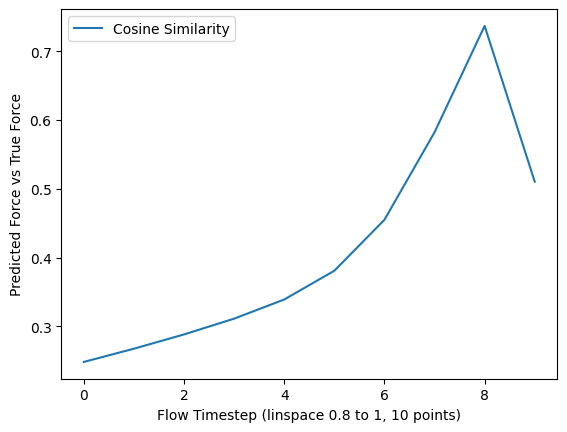

In [79]:
# plt.plot(all_ratios, label = "Ratios")
# plt.plot(all_errors, label = "Relative Errors")
plt.plot(all_cos_sims, label = "Cosine Similarity")
plt.ylabel("Predicted Force vs True Force")
plt.xlabel("Flow Timestep (linspace 0.8 to 1, 10 points)")
plt.legend()

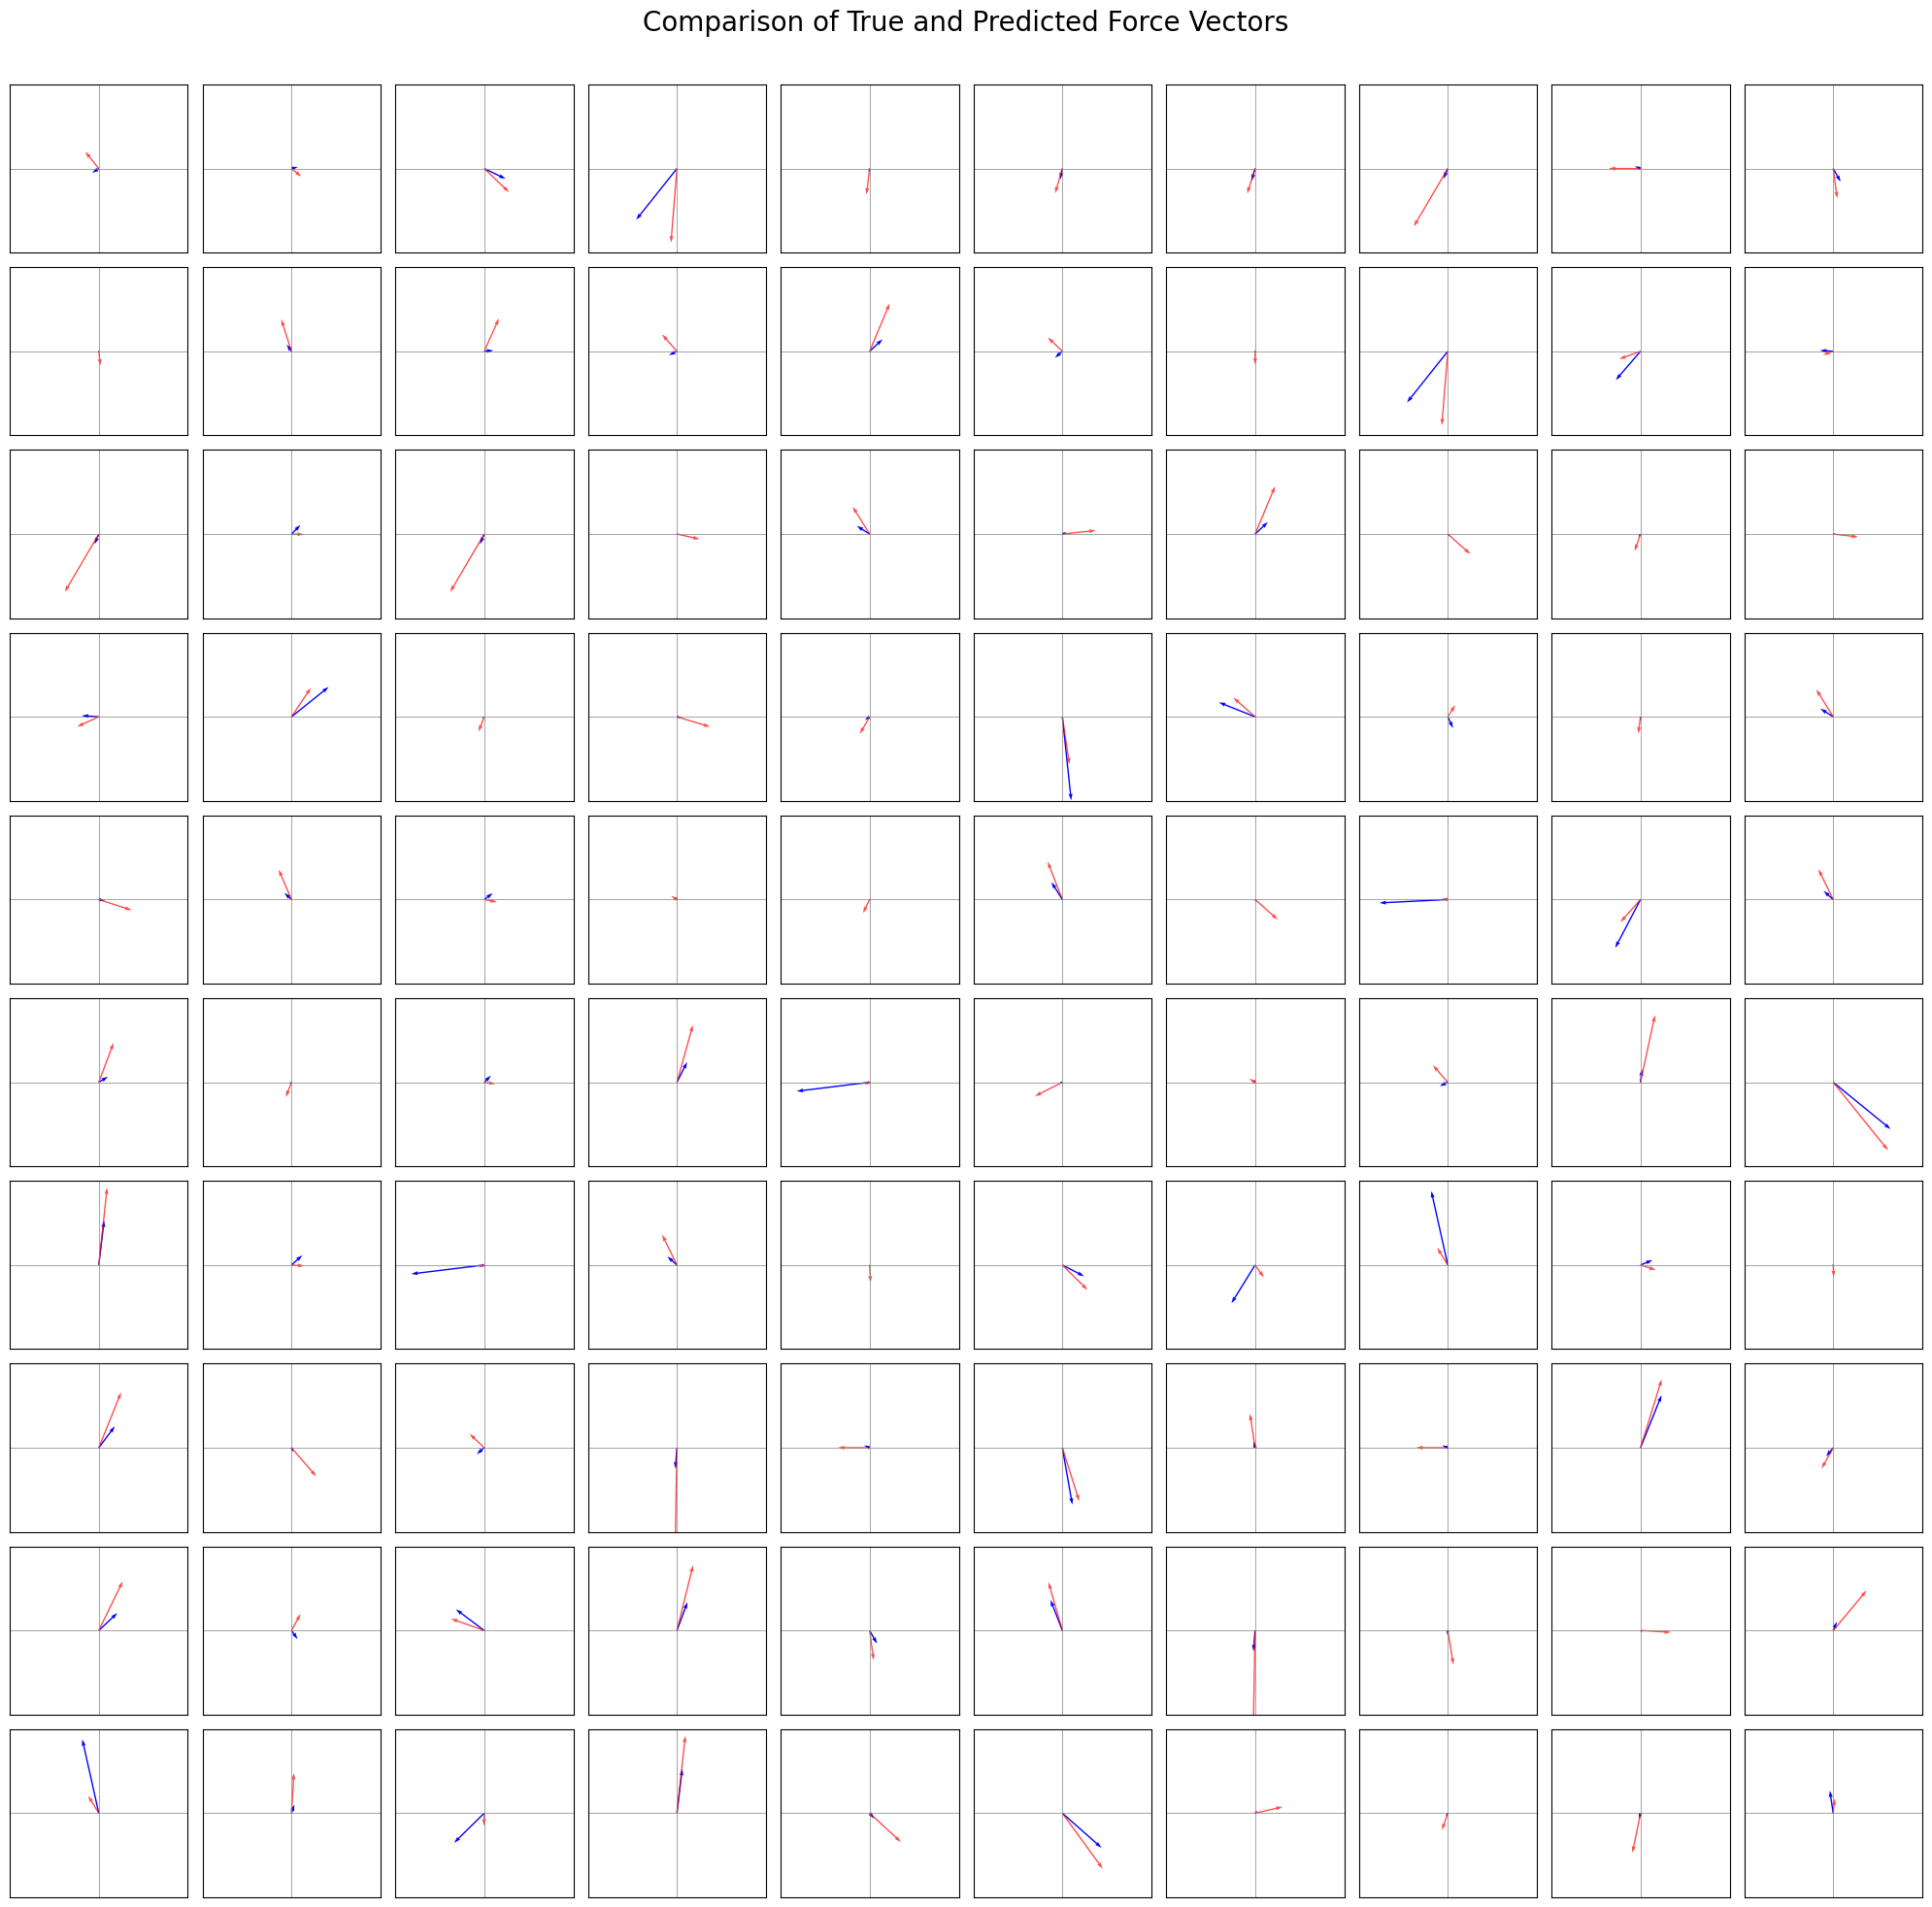

In [80]:
# sample some forces from all_forces and all_pred forces and plot them as arrows

# Generating the plots
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
fig.suptitle('Comparison of True and Predicted Force Vectors', fontsize=20)
_all_forces = torch.cat(all_forces).detach().cpu()
_all_pred_forces = torch.cat(all_pred_forces).detach().cpu()
# Normalize to unit vectors
# _all_forces = _all_forces / torch.norm(_all_forces, dim=1).unsqueeze(-1)
# _all_pred_forces = _all_pred_forces / torch.norm(_all_pred_forces, dim=1).unsqueeze(-1)

for i in range(10):
    for j in range(10):
        idx = torch.randint(0, len(all_forces), (1,)).item()
        
        
        ax = axes[i, j]
        ax.quiver(0, 0, _all_forces[idx, 0], _all_forces[idx, 1], angles='xy', scale_units='xy', scale=1, color='blue')
        ax.quiver(0, 0, _all_pred_forces[idx, 0], _all_pred_forces[idx, 1], angles='xy', scale_units='xy', scale=1, color='red', alpha=0.7)
        
        ax.axhline(0, color='grey', lw=0.5)
        ax.axvline(0, color='grey', lw=0.5)
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.grid(True, which='both', linestyle='--', lw=0.5)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

torch.Size([200000, 2]) torch.Size([200000, 2])


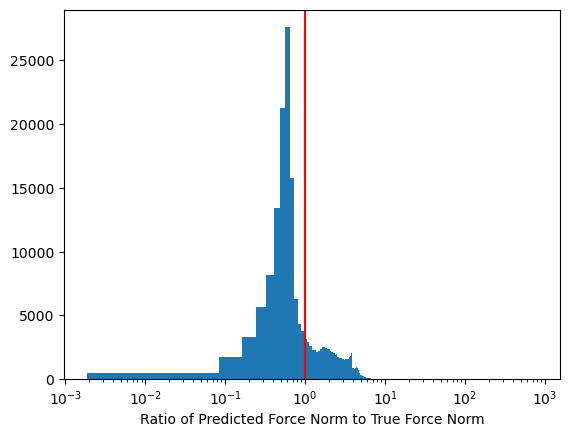

In [66]:
# plot histogram of ratios between predicted and true forces
print(_all_forces.shape, _all_pred_forces.shape)
ratios = torch.norm(_all_pred_forces, dim = 1) / torch.norm(_all_forces, dim = 1)
plt.figure()
plt.hist(get_numpy(ratios), bins = 10000)
plt.xscale("log")
plt.xlabel("Ratio of Predicted Force Norm to True Force Norm")
plt.axvline(1, color = "red")